# Imputation Case Visualization

**Purpose.** Compare Raw, Tangram, gimVI, and REVISE spatial expression within selected ROIs, cell types, and marker genes.

**Inputs.** Use the selected part's reference H5AD, `Tangram_impute.csv`, `gimVI_impute.csv`, and the `REVISE_impute.h5ad` produced by the input-preparation section of the main imputation benchmark notebook.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the Sim2Real-ST inputs, complete the Tangram, gimVI, and REVISE workflows, and run the input-preparation section of `imputation_and_dropout.ipynb` before using this notebook.
2. **Start from released results.** Download the [Sim2Real-ST benchmark and Reproduced benchmark results](https://zenodo.org/records/21921802), then place the extracted files under the raw-data and result directories declared in the configuration section.

The released-results route uses the same part-specific directory contract configured below.

After completing either path, run this notebook from top to bottom.

## 1. Configuration

Define repository paths, the case output directory, and the default marker size.

In [4]:
# [CONFIG] Repository paths and plotting defaults
import os

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

source_path = "../.."
raw_data_path = f"{source_path}/raw_data/Sim2Real-ST/imputation"
result_path = f"{source_path}/results/imputation"
output_dir = f"{source_path}/output/imputation_benchmark/case"
square_size = 16

os.makedirs(output_dir, exist_ok=True)

## 2. Input preparation and plotting helpers

Attach reference observations and spatial coordinates to Tangram and gimVI CSV matrices in memory, then define the shared case-plotting function.

In [ ]:
# [DEFINE] Reference, baseline CSV, and REVISE loaders
BASELINE_FILES = {
    "Tangram": "Tangram_impute.csv",
    "gimVI": "gimVI_impute.csv",
}


def _ordered_overlap(reference_names, candidate_names):
    candidate_set = set(candidate_names)
    return pd.Index([name for name in reference_names if name in candidate_set])


def load_reference(part):
    return sc.read_h5ad(f"{raw_data_path}/{part}/selected_xenium.h5ad")


def load_baseline_expression(method, part):
    reference = load_reference(part)
    expression = pd.read_csv(
        f"{result_path}/{part}/{BASELINE_FILES[method]}", index_col=0
    )
    cell_names = _ordered_overlap(reference.obs_names, expression.index)
    reference_aligned = reference[cell_names]
    prediction = ad.AnnData(
        X=expression.loc[cell_names].to_numpy(),
        obs=reference_aligned.obs.copy(),
        var=pd.DataFrame(index=expression.columns.copy()),
    )
    prediction.obsm["spatial"] = np.asarray(
        reference_aligned.obsm["spatial"]
    ).copy()
    return prediction


def load_revise_expression(part):
    return sc.read_h5ad(f"{result_path}/{part}/REVISE_impute.h5ad")

In [7]:
# [DEFINE] Spatial expression case plotting
def plot_imputation_case(
    highlight_dataset, 
    datasets,
    highlight_celltype='T', 
    gene='CD3D',
    xlim=(0, 4000), 
    ylim=(0, 4000),
    square_size=10, 
    save_dir="./figure", 
    tag=None,
    nrows=5,
    ncols=1,
    figsize=(6, 30)
    ):
    """Plot one cell-type overview and four method-specific expression panels.

    Args:
        highlight_dataset: AnnData and label used for the cell-type overview.
        datasets: AnnData and label pairs shown in the expression rows.
        highlight_celltype: Level1 cell type highlighted in red.
        gene: Marker gene displayed in every method panel.
        xlim: Horizontal ROI limits.
        ylim: Vertical ROI limits.
        square_size: Scatter-marker size control.
        save_dir: Directory for the PDF output.
        tag: Optional filename prefix.
        nrows: Number of subplot rows.
        ncols: Number of subplot columns.
        figsize: Figure dimensions.
    """

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    def sanitize_filename(s):
        return str(s).replace('/', '_').replace('\\', '_')

    # Reds range (global across all datasets)
    all_values = []
    for adata, _ in datasets:
        if gene in adata.var_names:
            expr = adata[:, gene].X
            expr = expr.toarray().flatten() if hasattr(expr, 'toarray') else expr.flatten()
            all_values.extend(expr)
    global_vmin, global_vmax = (np.min(all_values), np.max(all_values)) if all_values else (0, 1)

    # Blues range (non-highlight cells across all datasets)
    all_values_blue = []
    for adata, _ in datasets:
        if gene in adata.var_names:
            mask = (adata.obs['Level1'].values != highlight_celltype) if 'Level1' in adata.obs.columns else np.ones(adata.n_obs, dtype=bool)
            if np.any(mask):
                expr = adata[:, gene].X
                expr = expr.toarray().flatten() if hasattr(expr, 'toarray') else expr.flatten()
                all_values_blue.extend(expr[mask])
    blue_vmin, blue_vmax = (np.min(all_values_blue), np.max(all_values_blue)) if all_values_blue else (global_vmin, global_vmax)

    # nrows x ncols, figsize provided as parameter
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()  # Just in case

    # Row 0: cell type highlight overview
    ax0 = axes[0]
    adata_hl, name_hl = highlight_dataset
    if 'Level1' in adata_hl.obs.columns:
        all_level1_types = sorted(list(set(adata_hl.obs['Level1'].unique())))
        color_map = {ct: '#B0B0B0' for ct in all_level1_types}
        color_map[highlight_celltype] = '#D62728'
        x = adata_hl.obs['x'].values
        y = adata_hl.obs['y'].values
        labels = adata_hl.obs['Level1'].values
        colors_array = [color_map.get(label, 'gray') for label in labels]
        ax0.scatter(x, y, c=colors_array, s=square_size**2, marker='.', edgecolors='none', alpha=0.8)
        ax0.set_aspect('equal'); ax0.grid(False); ax0.invert_yaxis()
        ax0.set_xlim(xlim); ax0.set_ylim(ylim)
        ax0.set_title(f'Cell Type Highlight\n{highlight_celltype} ({name_hl})', fontsize=12, fontweight='bold')
        ax0.set_xticks([]); ax0.set_yticks([])
    else:
        ax0.text(0.5, 0.5, f'{name_hl}\nNo Level1 data', ha='center', va='center', transform=ax0.transAxes)
        ax0.set_xlim(0, 1); ax0.set_ylim(0, 1)

    # Rows 1-(nrows-1): gene expression per dataset (Blues non-highlight first, Reds highlight on top)
    for i in range(1, nrows):
        ax = axes[i]
        if i-1 < len(datasets):
            adata, name = datasets[i-1]
            x = adata.obs['x'].values
            y = adata.obs['y'].values
            if gene in adata.var_names:
                expr = adata[:, gene].X
                expr = expr.toarray().flatten() if hasattr(expr, 'toarray') else expr.flatten()
            else:
                expr = np.zeros(len(x))

            if 'Level1' in adata.obs.columns:
                highlight_mask = (adata.obs['Level1'].values == highlight_celltype)
            else:
                highlight_mask = np.zeros(len(x), dtype=bool)

            # Non-highlight (Blues), sorted ascending
            idx_other = np.where(~highlight_mask)[0]
            if idx_other.size > 0:
                order_other = np.argsort(expr[idx_other])
                i_other = idx_other[order_other]
                ax.scatter(x[i_other], y[i_other], c=expr[i_other], cmap='Blues',
                           s=square_size**2, marker='.', vmin=blue_vmin, vmax=blue_vmax, edgecolors='none')

            # Highlight (Reds), sorted ascending
            idx_hl = np.where(highlight_mask)[0]
            if idx_hl.size > 0:
                order_hl = np.argsort(expr[idx_hl])
                i_hl = idx_hl[order_hl]
                ax.scatter(x[i_hl], y[i_hl], c=expr[i_hl], cmap='Reds',
                           s=square_size**2, marker='.', vmin=global_vmin, vmax=global_vmax, edgecolors='none')

            ax.set_aspect('equal'); ax.grid(False); ax.invert_yaxis()
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_title(f'{name}\n{gene} Expression', fontsize=12, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.set_visible(False)

    # Two colorbars at the right
    fig.suptitle(f'{highlight_celltype} highlight & {gene}', fontsize=14, fontweight='bold')

    # Leave room on the right for colorbars
    plt.tight_layout()
    plt.subplots_adjust(top=0.90, left=0.10, right=0.78, hspace=0.20)

    # The colorbar axes positions may be adjusted depending on the nrows, but for default (5,1) keep as before:
    cbar_ax_red = fig.add_axes([0.82, 0.62, 0.03, 0.30])
    cbar_ax_blue = fig.add_axes([0.82, 0.20, 0.03, 0.30])

    sm_red = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=global_vmin, vmax=global_vmax))
    sm_red.set_array([])
    cbar_red = fig.colorbar(sm_red, cax=cbar_ax_red)
    cbar_red.set_label(f'Highlight ({highlight_celltype}) {gene}', fontsize=11, rotation=270, labelpad=18)

    sm_blue = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=blue_vmin, vmax=blue_vmax))
    sm_blue.set_array([])
    cbar_blue = fig.colorbar(sm_blue, cax=cbar_ax_blue)
    cbar_blue.set_label(f'Non-highlight {gene}', fontsize=11, rotation=270, labelpad=18)

    # Save PNG and PDF
    prefix = f"{sanitize_filename(tag)}_" if tag is not None else ""
    filename_base = os.path.join(save_dir, f"{prefix}{sanitize_filename(highlight_celltype)}_{sanitize_filename(gene)}")
    # plt.savefig(filename_base + ".png", bbox_inches='tight', dpi=300)
    # print(f"Saved: {filename_base}.png")
    plt.savefig(filename_base + ".pdf", bbox_inches='tight')
    print(f"Saved:{filename_base}.pdf")
    plt.show()
    plt.close(fig)

## 3. Case definitions and visualization

The ROI, marker genes, cell types, coordinate offsets, marker size, and plotting algorithm below retain the original case definitions. Increase `figsize` if larger markers overlap.


=== Processing part3 ===
- part3 | ROI (0, 4000)x(0, 4000) | cell=T | gene=TRAC
Saved:output/imputation_benchmark/case/part3_T_TRAC.pdf


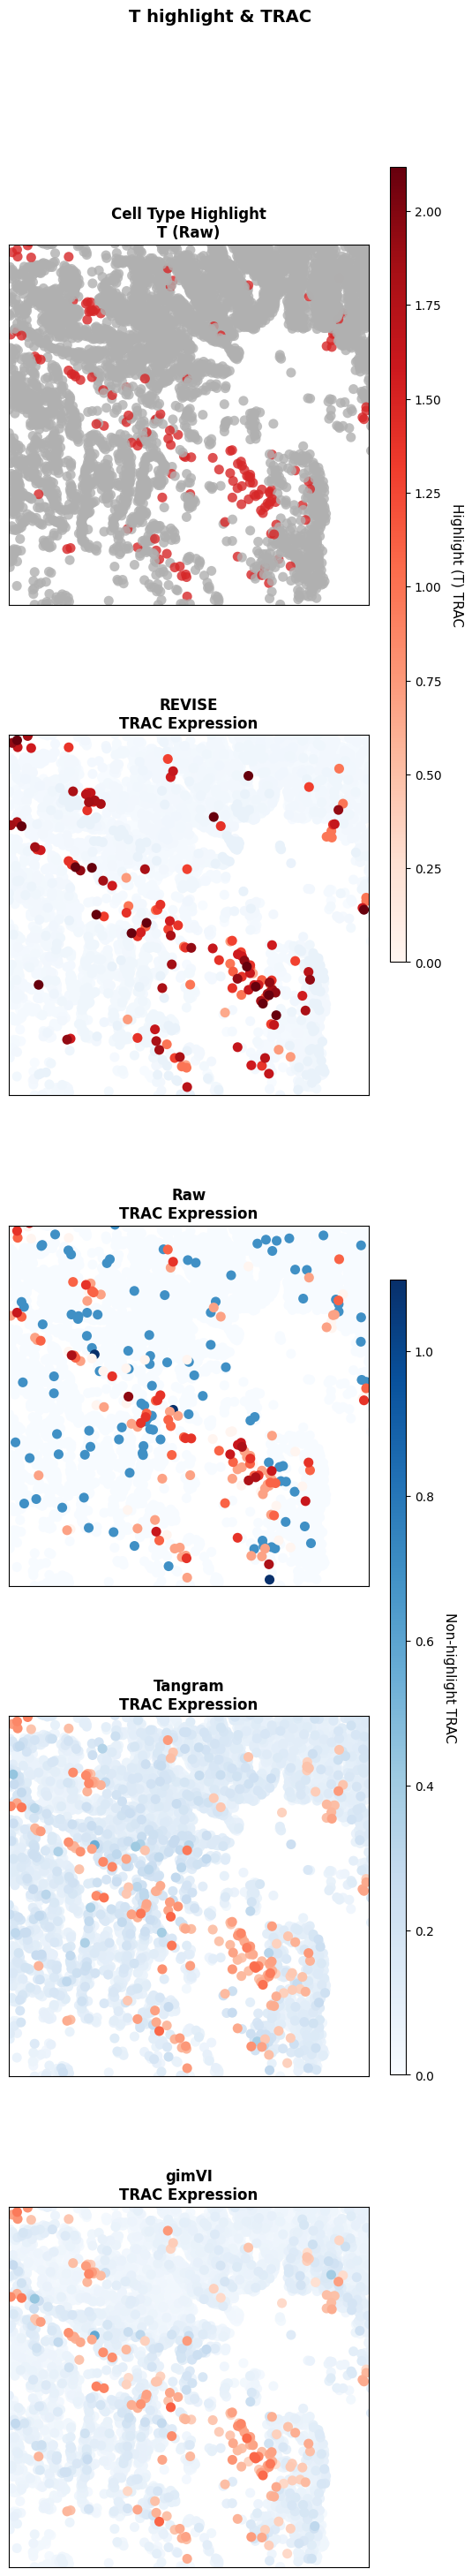

- part3 | ROI (0, 4000)x(0, 4000) | cell=T | gene=TRBC2
Saved:output/imputation_benchmark/case/part3_T_TRBC2.pdf


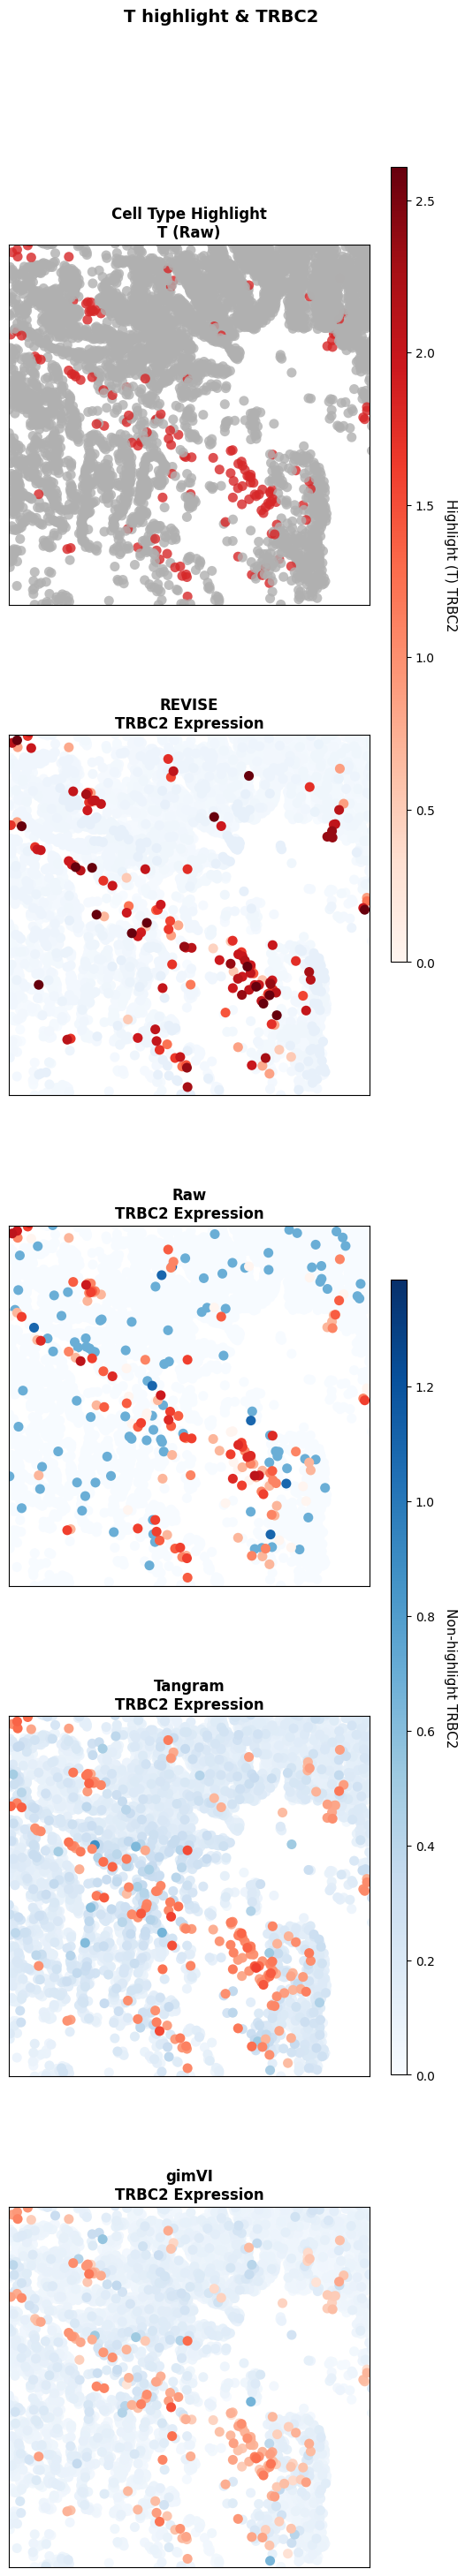

- part3 | ROI (0, 1500)x(6000, 7500) | cell=Vascular EC | gene=CDH5
Saved:output/imputation_benchmark/case/part3_Vascular EC_CDH5.pdf


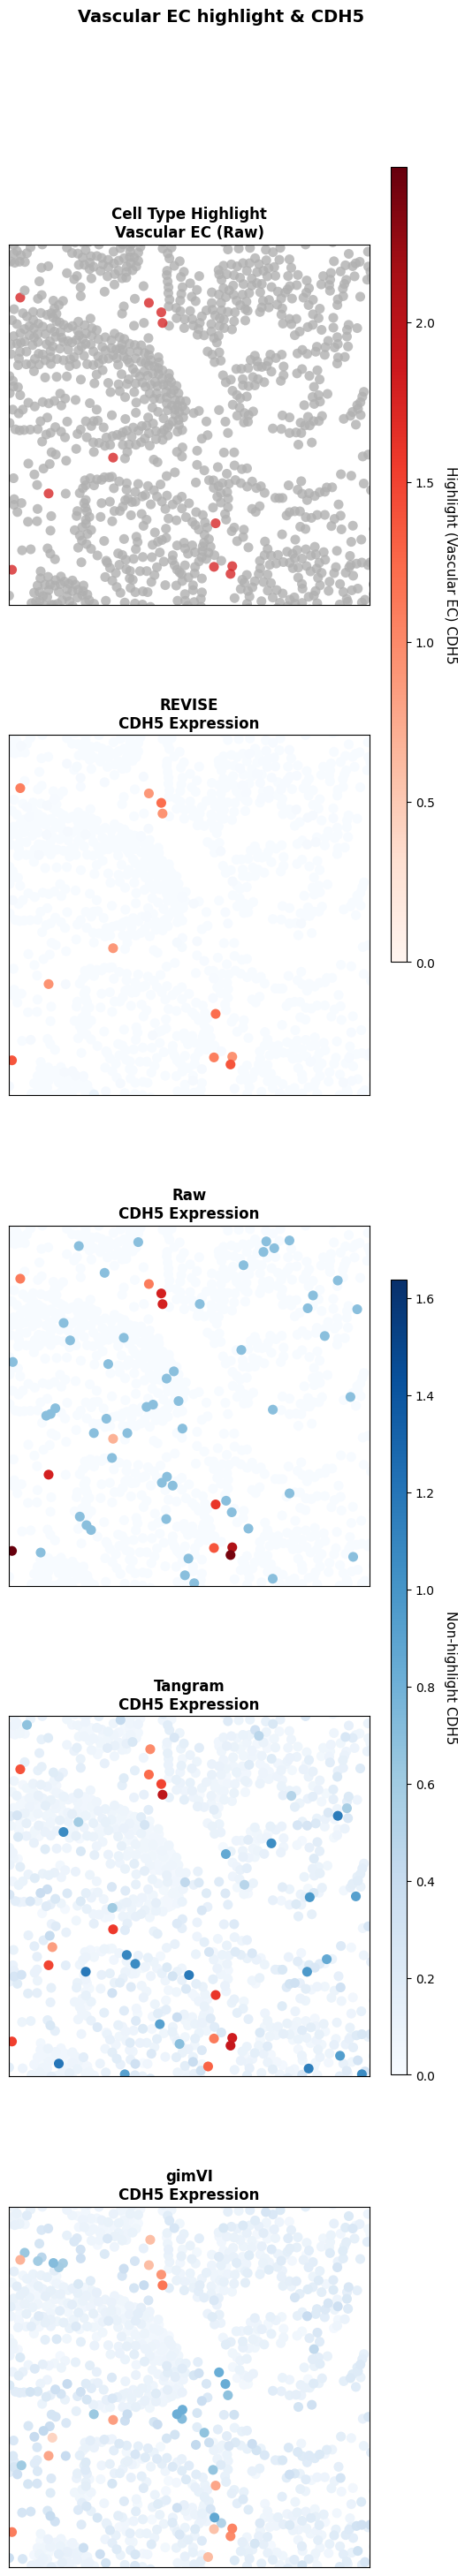

- part3 | ROI (0, 1500)x(6000, 7500) | cell=Vascular EC | gene=VWF
Saved:output/imputation_benchmark/case/part3_Vascular EC_VWF.pdf


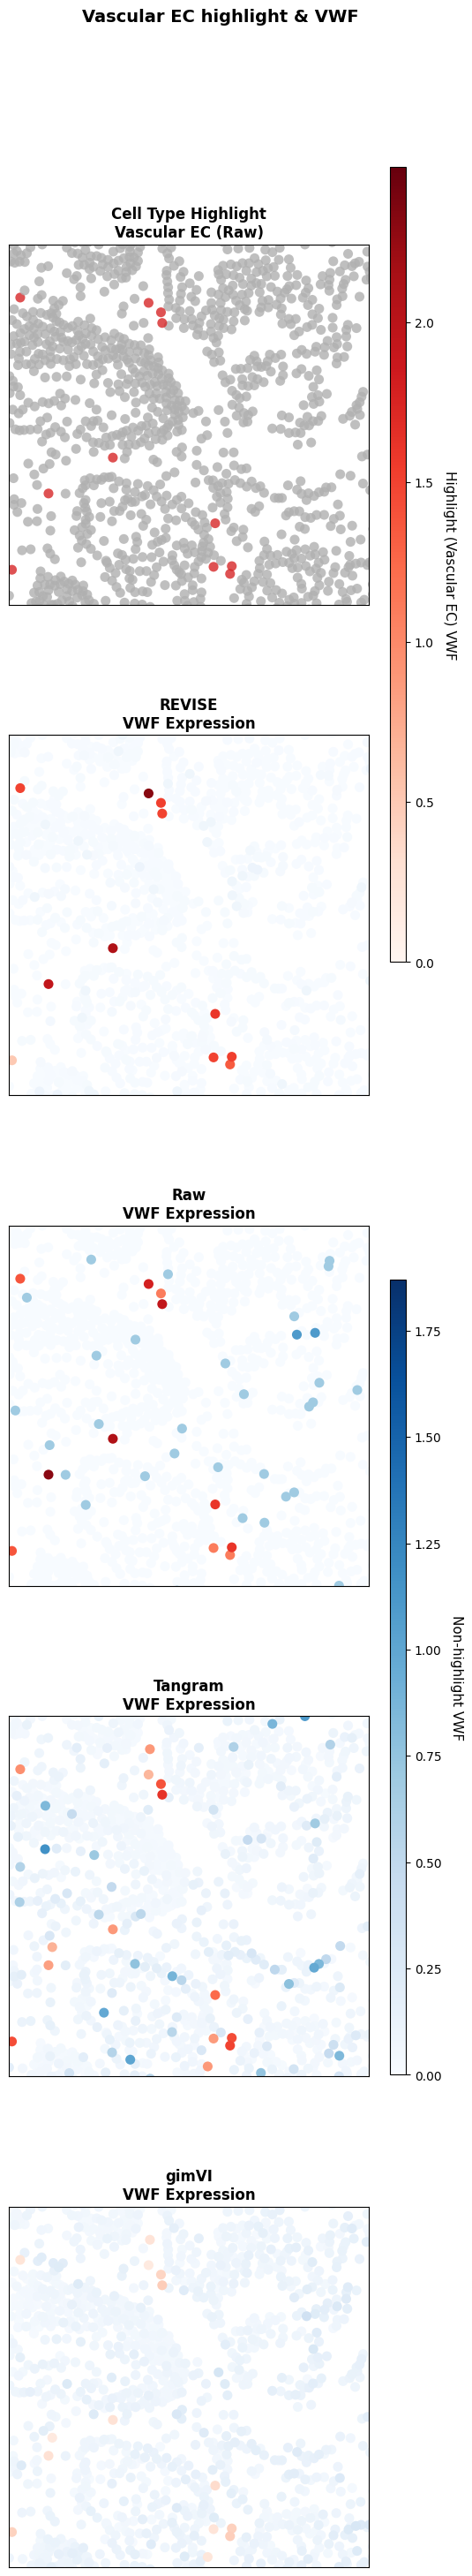


=== Processing part2 ===
- part2 | ROI (0, 4000)x(4000, 8000) | cell=T | gene=GZMA
Saved:output/imputation_benchmark/case/part2_T_GZMA.pdf


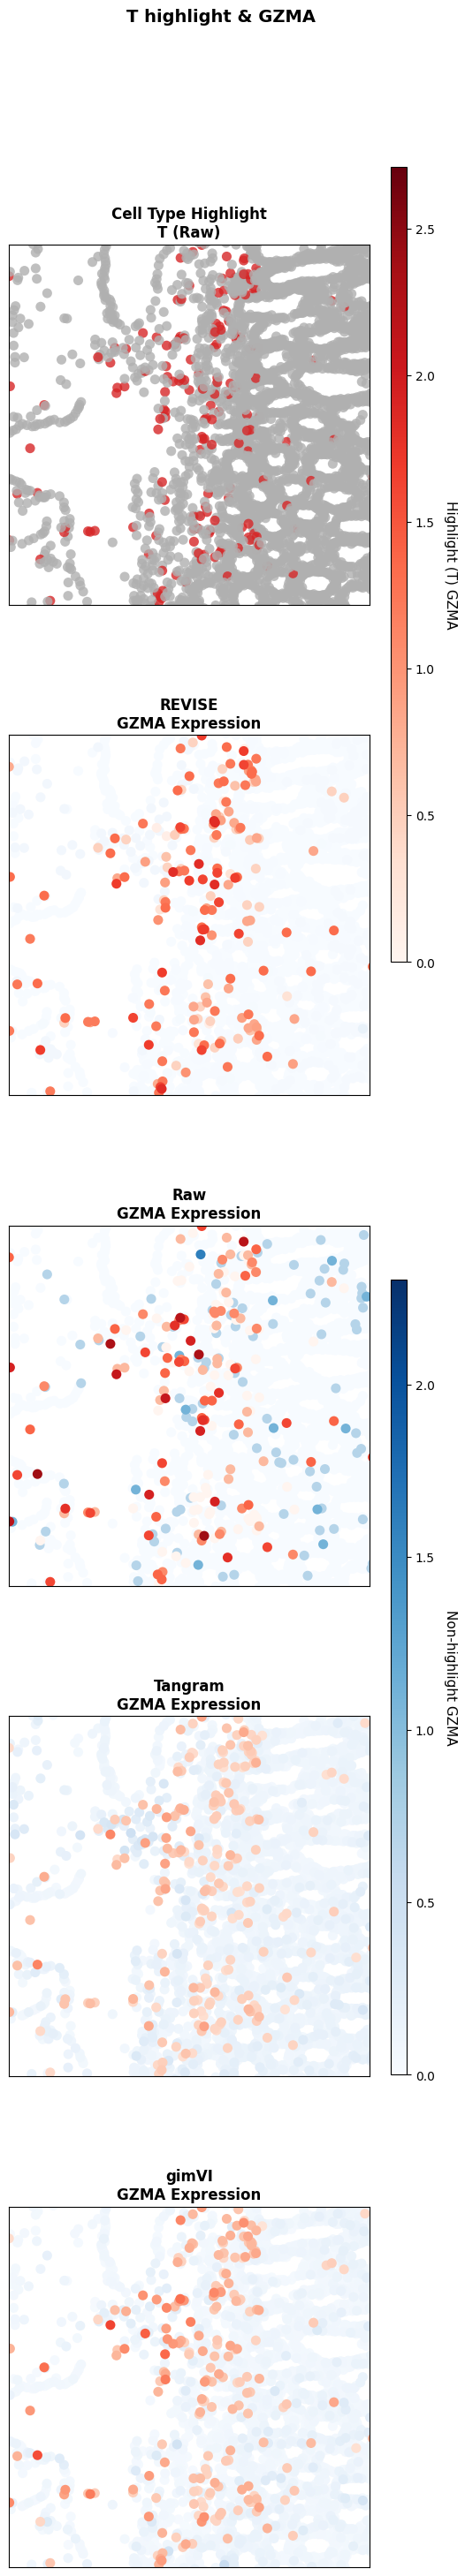

- part2 | ROI (0, 4000)x(4000, 8000) | cell=Mono/Macro | gene=CYBB
Saved:output/imputation_benchmark/case/part2_Mono_Macro_CYBB.pdf


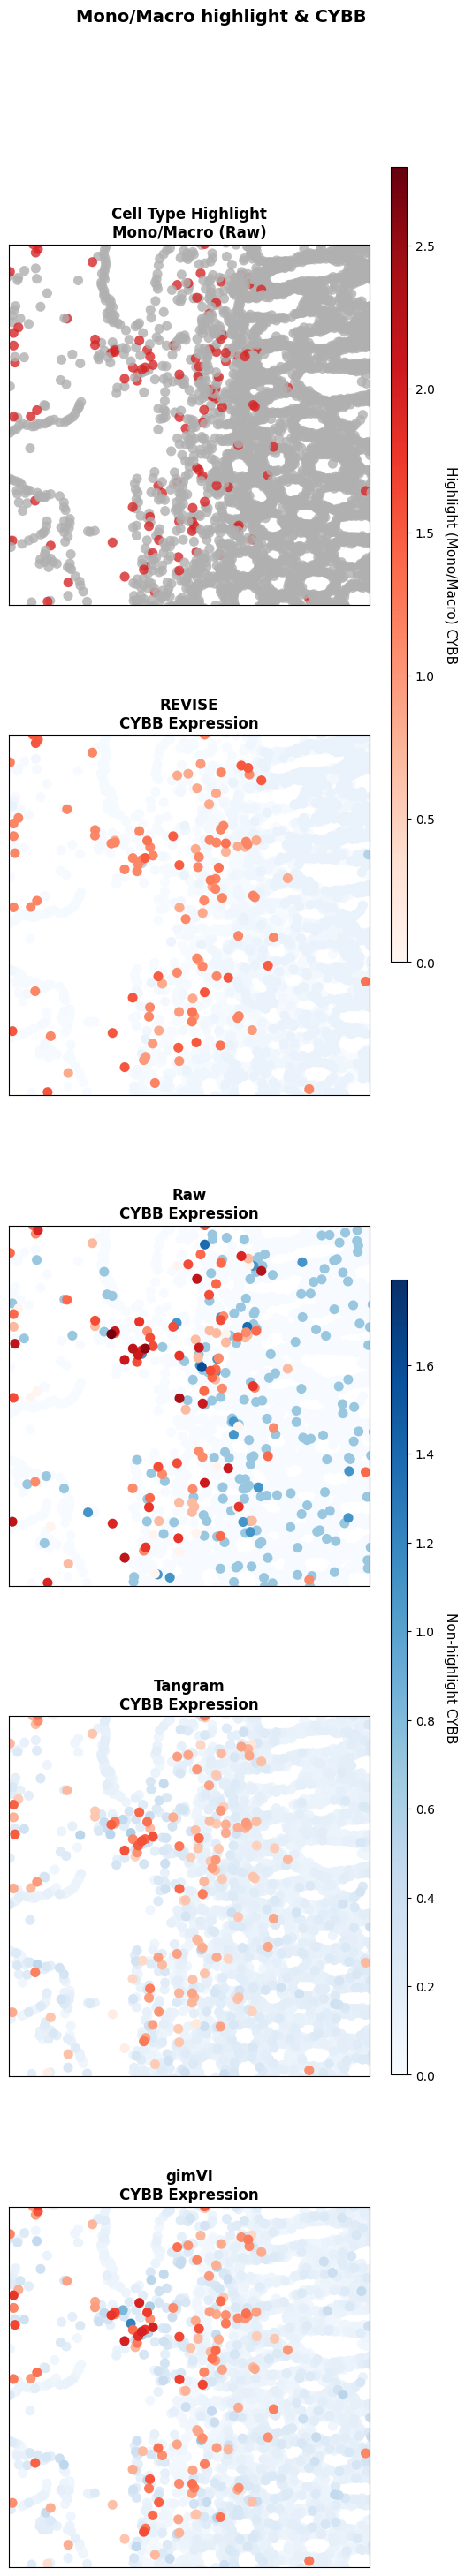


=== Processing part1 ===
- part1 | ROI (0, 2000)x(0, 2000) | cell=T | gene=CD3E
Saved:output/imputation_benchmark/case/part1_T_CD3E.pdf


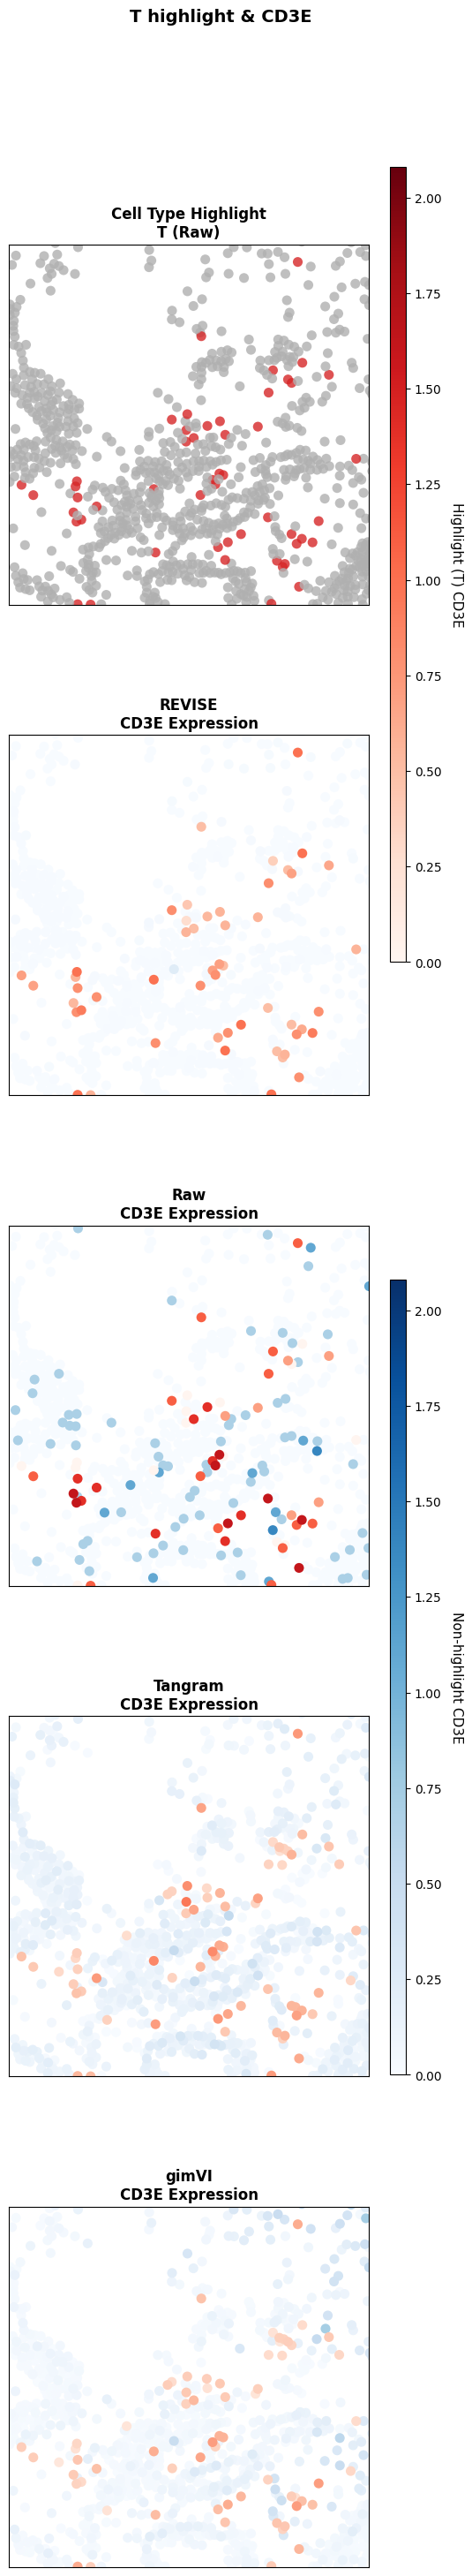

- part1 | ROI (0, 2000)x(0, 2000) | cell=Vascular EC | gene=PLVAP
Saved:output/imputation_benchmark/case/part1_Vascular EC_PLVAP.pdf


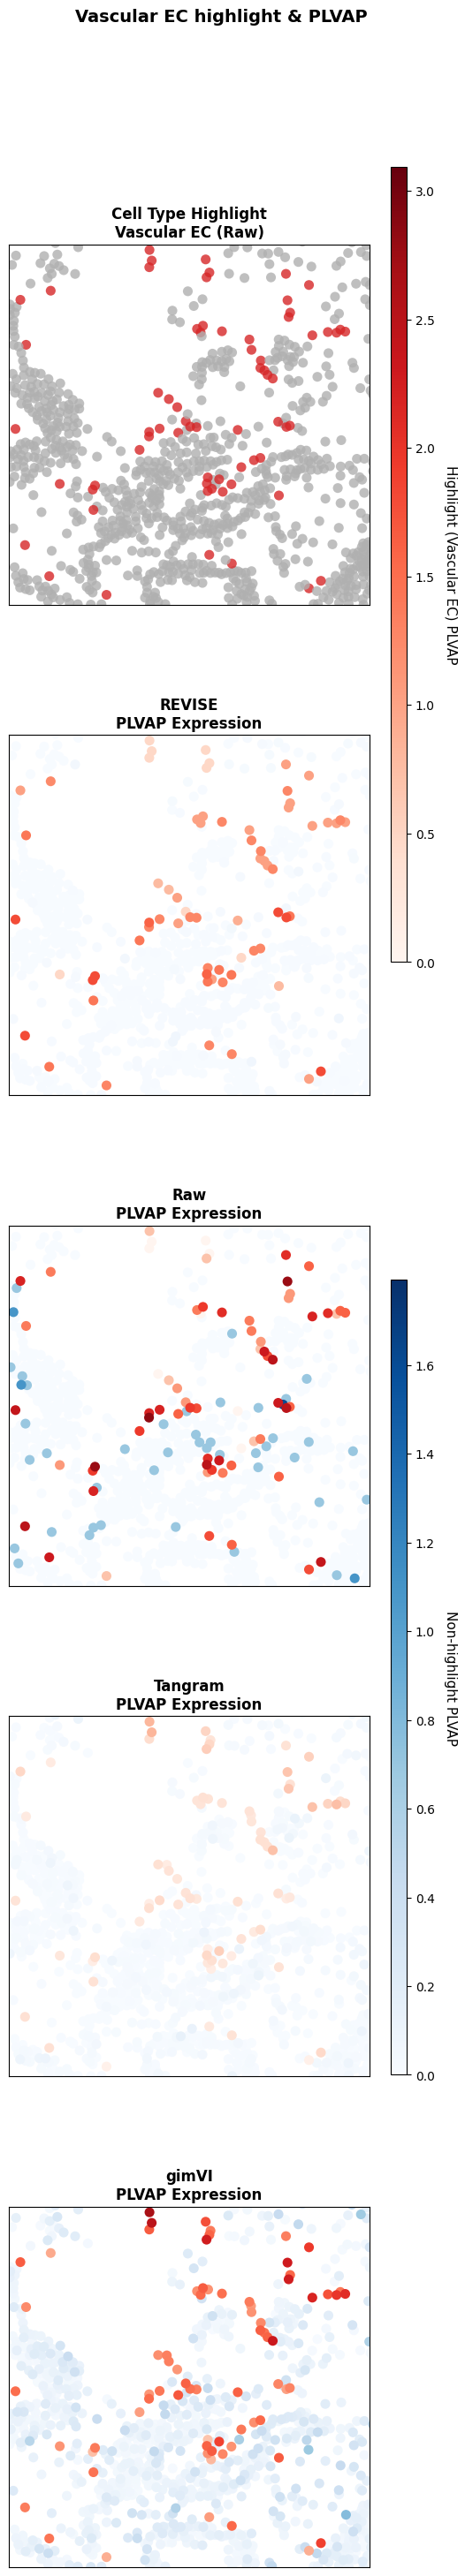

In [14]:
# [RUN] Render the configured ROI, cell-type, and marker-gene cases
# Each part can contain multiple ROI tasks and marker genes.
parts_cfg = [
    {
        "part": "part3",
        "tasks": [
            {"xlim": (0, 4000), "ylim": (0, 4000), "genes": ["TRAC", "TRBC2"], "cell_type": "T",           "square_size": square_size},
            {"xlim": (0, 1500), "ylim": (6000, 7500), "genes": ["CDH5", "VWF"], "cell_type": "Vascular EC", "square_size": square_size},
        ],
    },
    {
        "part": "part2",
        "tasks": [
            {"xlim": (0, 4000), "ylim": (4000, 8000), "genes": ["GZMA"], "cell_type": "T",          "square_size": square_size},
            {"xlim": (0, 4000), "ylim": (4000, 8000), "genes": ["CYBB"], "cell_type": "Mono/Macro", "square_size": square_size},
        ],
    },
    {
        "part": "part1",
        "tasks": [
            {"xlim": (0, 2000), "ylim": (0, 2000), "genes": ["CD3E"], "cell_type": "T",           "square_size": square_size},
            {"xlim": (0, 2000), "ylim": (0, 2000), "genes": ["PLVAP"], "cell_type": "Vascular EC", "square_size": square_size},
        ],
    },
]

# Spatial offsets used by the original case definitions.
def get_offset(part):
    if "part1" in part:
        return np.array([42000, 8000])
    elif "part2" in part:
        return np.array([52000, 13000])
    elif "part3" in part:
        return np.array([60000, 10000])
    else:
        print(f"Warning: No specific part (part1/2/3) identified for '{part}'. No spatial offset applied.")
        return np.array([0, 0])

# Render every configured case.
for pcfg in parts_cfg:
    part = pcfg["part"]
    print(f"\n=== Processing {part} ===")

    # Load Raw, baseline, and prepared REVISE expression.
    adata_REVISE = load_revise_expression(part)
    adata_Raw = load_reference(part)
    adata_Tangram = load_baseline_expression("Tangram", part)
    adata_gimVI = load_baseline_expression("gimVI", part)

    # Translate spatial coordinates to the part-specific local frame.
    offset = get_offset(part)
    for ad in [adata_REVISE, adata_Raw, adata_Tangram, adata_gimVI]:
        ad.obsm['spatial'] = ad.obsm['spatial'] - offset
        ad.obs[['x', 'y']] = ad.obsm['spatial']

    # Apply the original log1p transformation.
    for ad in [adata_REVISE, adata_Raw, adata_Tangram, adata_gimVI]:
        sc.pp.log1p(ad)

    # Assemble the unfiltered method panels.
    datasets = [
        (adata_REVISE, "REVISE"),
        (adata_Raw,    "Raw"),
        (adata_Tangram,"Tangram"),
        (adata_gimVI,  "gimVI"),
    ]

    # Render each ROI, cell type, marker size, and gene combination.
    for task in pcfg["tasks"]:
        xlim = task["xlim"]
        ylim = task["ylim"]
        cell_type_highlight = task["cell_type"]
        square_size = task["square_size"]
        genes = task["genes"]

        # Build highlighted and non-highlighted cell subsets.
        adata_REVISE_subset = adata_REVISE[adata_REVISE.obs['Level1'] == cell_type_highlight]
        adata_Raw_subset    = adata_Raw[adata_Raw.obs['Level1'] == cell_type_highlight]
        adata_Tangram_subset= adata_Tangram[adata_Tangram.obs['Level1'] == cell_type_highlight]
        adata_gimVI_subset  = adata_gimVI[adata_gimVI.obs['Level1'] == cell_type_highlight]

        adata_REVISE_non_marker = adata_REVISE[adata_REVISE.obs['Level1'] != cell_type_highlight]
        adata_Raw_non_marker    = adata_Raw[adata_Raw.obs['Level1'] != cell_type_highlight]
        adata_Tangram_non_marker= adata_Tangram[adata_Tangram.obs['Level1'] != cell_type_highlight]
        adata_gimVI_non_marker  = adata_gimVI[adata_gimVI.obs['Level1'] != cell_type_highlight]

        datasets_level = [
            (adata_Raw,             "Raw"),
            (adata_Raw_subset,      "Raw"),
            (adata_Raw_non_marker,  "Raw"),
        ]
        dataset_subset = [
            (adata_REVISE_subset, "REVISE"),
            (adata_Raw_subset,    "Raw"),
            (adata_Tangram_subset,"Tangram"),
            (adata_gimVI_subset,  "gimVI"),
        ]
        datasets_non_marker = [
            (adata_REVISE_non_marker, "REVISE"),
            (adata_Raw_non_marker,    "Raw"),
            (adata_Tangram_non_marker,"Tangram"),
            (adata_gimVI_non_marker,  "gimVI"),
        ]


        # Render one figure per marker gene.
        for gene in genes:
            print(f"- {part} | ROI {xlim}x{ylim} | cell={cell_type_highlight} | gene={gene}")
            plot_imputation_case(
                highlight_dataset=datasets_level[0],
                datasets=datasets,
                highlight_celltype=cell_type_highlight,
                gene=gene,
                xlim=xlim,
                ylim=ylim,
                square_size=square_size,
                save_dir=output_dir,
                tag=part,
                nrows=5,
                ncols=1,
                figsize=(6, 30)
            )

## 4. Outputs

Each configured marker-gene case is written as a PDF under `output/imputation_benchmark/case/`.